# Kerr relative error on fig 2b

Paper traces are **relative**: fig 2b subtracts each eye's `nanmedian(k_phi)` / `nanmedian(k_theta)` on the **full block**, then plots 0–8 s. Kerr's systematic bias is a function of **unzeroed** reported $(\phi, \theta)$ (roundest-ellipse / camera origin). After a global rest-zero, a large part of that bias is a constant and disappears. Two leftovers are easy to mix up:

- **Position offset** `hypot(Δφ, Δθ)` between the two rest-centered traces. A nearly constant shift (different rest after correction) can look like several degrees even when the eyes travel almost the same path.
- **Travel distance** — inter-sample angular step, and the path length of those steps. That is the kinematic quantity (how far the eye moved), and it is usually much smaller than the position hypot.

**Pipeline**

1. Rebuild Kerr vs ground-truth on the 8 mm / 13 mm ellipse simulation table.
2. Heatmap in ground-truth space (−60…60°): 1° bins colored by $|\mathrm{Kerr}-\mathrm{GT}|$, 5° vectors from true angle toward where Kerr placed it.
3. Interpolate the error field in **Kerr-reported** $(\phi, \theta)$ and subtract it from `PV_126_block_007`.
4. Re-zero both original and corrected traces (full-block nanmedian) and compare on the fig 2b window.

**Assumptions**

- Geometry transfer: both real eyes share this error field as a function of reported Kerr angle (8 mm eye, 13 mm camera distance).
- Lookup uses unzeroed `(k_phi, k_theta)` from the recording's roundest-ellipse Kerr origin, not rest-centered coordinates.
- Heatmap arrows show algorithm displacement (GT → Kerr), not the inverse correction applied to the traces.


## 0. Setup


In [1]:
%matplotlib inline
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
from scipy.interpolate import LinearNDInterpolator

plt.ioff()
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42

REPO = Path.cwd()
if not (REPO / "src" / "eye_tracking_system_tools").is_dir():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "eye_tracking_system_tools").is_dir():
            REPO = p
            break

sys.path.insert(0, str(REPO / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

from eye_tracking_system_tools.analysis.block_registry import read_paper_registry
from eye_tracking_system_tools.analysis.eye_trace_io import load_block_eyes
from eye_tracking_system_tools.analysis.species_traces import pick_trace_window
from eye_tracking_system_tools.figures.plotting_functions import TRACE_L, TRACE_R

HERE = REPO / "development" / "kerr_relative_error"
SIM_CSV = HERE / "ellipse_angle_mapping_correct_diameter_08mm_distance_13mm.csv"
OUT = HERE / "outputs"
OUT.mkdir(exist_ok=True)

BLOCK_KEY = "PV_126_block_007"
REGISTRY = REPO / "configs" / "paper_blocks.yaml"
START_S = 0.0
END_S = 80
SPAN_DEG = 60
QUIVER_STEP_DEG = 5
RADIAL_CUT_DEG = 35.0
MIN_STEP_DEG = 0.2
SIM_REF_X = 640 // 2
SIM_REF_Y = 480 // 2

print("REPO :", REPO)
print("HERE :", HERE)
print("OUT  :", OUT)
print("SIM  :", SIM_CSV, "exists=", SIM_CSV.is_file())


REPO : /Users/nimi/Projects/PETS
HERE : /Users/nimi/Projects/PETS/development/kerr_relative_error
OUT  : /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs
SIM  : /Users/nimi/Projects/PETS/development/kerr_relative_error/ellipse_angle_mapping_correct_diameter_08mm_distance_13mm.csv exists= True


## 1. Rebuild Kerr vs ground-truth

Same ellipse → angle math as the source simulation notebook and `BlockSync.kerr`. Simulation reference is the image center `(320, 240)`. Errors: `err_phi = phi − x_angle`, `err_theta = theta − y_angle`.


In [2]:
def kerr(df: pd.DataFrame, aEC: float, bEC: float) -> tuple[float, pd.DataFrame]:
    """Ellipse centres → Kerr (r, phi, theta) in degrees."""
    theta_values = np.full(len(df), np.nan)
    phi_values = np.full(len(df), np.nan)
    r_values = np.full(len(df), np.nan)

    hw_values = df["ratio2"].to_numpy(dtype=float)
    aPC_values = df["center_x"].to_numpy(dtype=float)
    bPC_values = df["center_y"].to_numpy(dtype=float)
    valid_mask = np.isfinite(hw_values)

    sqrt_component = np.sqrt(np.clip(1.0 - hw_values[valid_mask] ** 2, 0.0, None))
    distances = np.sqrt((aPC_values[valid_mask] - aEC) ** 2 + (bPC_values[valid_mask] - bEC) ** 2)
    top = float(np.sum(sqrt_component * distances))
    bot = float(np.sum(1.0 - hw_values[valid_mask] ** 2))
    f_z = top / bot

    major = df["major_ax"].to_numpy(dtype=float)
    minor = df["minor_ax"].to_numpy(dtype=float)
    valid_major = np.isfinite(major)
    max_axes = np.maximum(major, minor)
    r_values[valid_major] = (2.0 * max_axes[valid_major]) / f_z

    valid_positions = np.isfinite(aPC_values) & np.isfinite(bPC_values)
    with np.errstate(invalid="ignore"):
        comp_p = np.arcsin((aPC_values[valid_positions] - aEC) / f_z)
        comp_t = np.arcsin(
            (bPC_values[valid_positions] - bEC) / (np.cos(comp_p) * f_z)
        )
    theta_values[valid_positions] = np.degrees(comp_t)
    phi_values[valid_positions] = np.degrees(comp_p)

    out = pd.DataFrame(
        {"r": r_values, "theta": theta_values, "phi": phi_values},
        index=df.index,
    )
    keep = [c for c in ("frame", "x_angle", "y_angle", "ratio2", "ratio1") if c in df.columns]
    return f_z, pd.concat([df[keep], out], axis=1)


def recenter_series(values: np.ndarray, median: float | None = None) -> tuple[np.ndarray, float]:
    vals = np.asarray(values, dtype=float)
    med = float(np.nanmedian(vals)) if median is None else float(median)
    if not np.isfinite(med):
        return vals.copy(), med
    return vals - med, med


sim_df = pd.read_csv(SIM_CSV, index_col=0)
sim_df["major_ax"] = np.maximum(sim_df["axs_1"], sim_df["axs_2"])
sim_df["minor_ax"] = np.minimum(sim_df["axs_1"], sim_df["axs_2"])
sim_df["ratio2"] = (sim_df["minor_ax"] / sim_df["major_ax"]).clip(0.0, 1.0)
sim_df["ratio1"] = sim_df["major_ax"] / sim_df["minor_ax"]

f_z, kerr_df = kerr(sim_df, aEC=SIM_REF_X, bEC=SIM_REF_Y)
kerr_df["x_bin"] = np.round(kerr_df["x_angle"]).astype(int)
kerr_df["y_bin"] = np.round(kerr_df["y_angle"]).astype(int)
kerr_df["err_phi"] = kerr_df["phi"] - kerr_df["x_angle"]
kerr_df["err_theta"] = kerr_df["theta"] - kerr_df["y_angle"]
kerr_df["err_mag"] = np.hypot(kerr_df["err_phi"], kerr_df["err_theta"])
kerr_df["r_gt"] = np.hypot(kerr_df["x_angle"], kerr_df["y_angle"])

finite = kerr_df["err_mag"].notna()
in_span = finite & (kerr_df["r_gt"] <= RADIAL_CUT_DEG)
print(f"f_z = {f_z:.4f}")
print(f"finite Kerr samples: {int(finite.sum())} / {len(kerr_df)}")
print(
    f"within r≤{RADIAL_CUT_DEG:g}° mean |error|: "
    f"{kerr_df.loc[in_span, 'err_mag'].mean():.3f}°  (n={int(in_span.sum())})"
)


f_z = 55.1417
finite Kerr samples: 14644 / 15367
within r≤35° mean |error|: 3.242°  (n=4088)


## 2. Error heatmap (ground-truth space)

Each 1° bin is the mean $|\mathrm{Kerr}-\mathrm{GT}|$ over simulation samples that round to that true $(\phi, \theta)$. Arrows sit on the 5° lattice and run in data units from the true angle to the Kerr-reported angle.


wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/kerr_error_heatmap.pdf


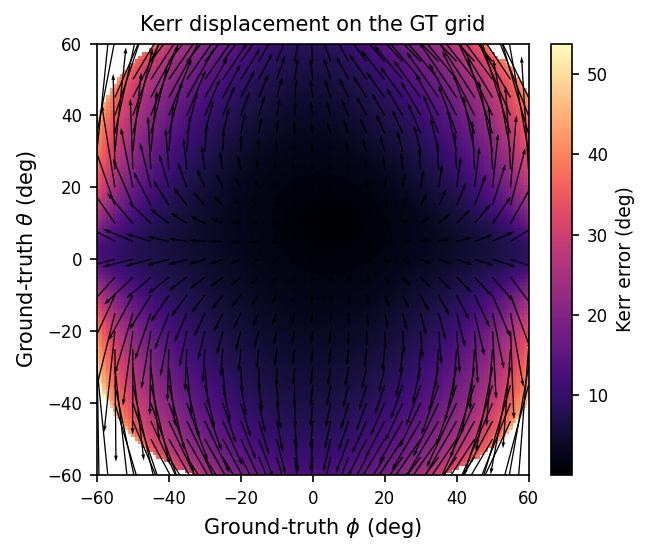

In [3]:
angles = np.arange(-SPAN_DEG, SPAN_DEG + 1, dtype=int)
n = angles.size
mag = np.full((n, n), np.nan)
dphi = np.full((n, n), np.nan)
dtheta = np.full((n, n), np.nan)
phi_grid = np.full((n, n), np.nan)
theta_grid = np.full((n, n), np.nan)

binned = (
    kerr_df.groupby(["x_bin", "y_bin"], as_index=False)
    .agg(
        err_mag=("err_mag", "mean"),
        err_phi=("err_phi", "mean"),
        err_theta=("err_theta", "mean"),
        phi=("phi", "mean"),
        theta=("theta", "mean"),
    )
)
ix = {v: i for i, v in enumerate(angles)}
for row in binned.itertuples(index=False):
    if row.x_bin not in ix or row.y_bin not in ix:
        continue
    i = ix[row.x_bin]
    j = ix[row.y_bin]
    mag[j, i] = row.err_mag
    dphi[j, i] = row.err_phi
    dtheta[j, i] = row.err_theta
    phi_grid[j, i] = row.phi
    theta_grid[j, i] = row.theta

fig, ax = plt.subplots(figsize=(4.6, 3.8), dpi=150)
mesh = ax.imshow(
    mag,
    origin="lower",
    extent=(-SPAN_DEG - 0.5, SPAN_DEG + 0.5, -SPAN_DEG - 0.5, SPAN_DEG + 0.5),
    cmap="magma",
    interpolation="nearest",
    aspect="equal",
)
cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Kerr error (deg)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

q_idx = np.arange(0, n, QUIVER_STEP_DEG)
qq = np.ix_(q_idx, q_idx)
x_q = angles[q_idx]
y_q = angles[q_idx]
X, Y = np.meshgrid(x_q, y_q)
U = phi_grid[qq] - X
V = theta_grid[qq] - Y
finite_q = np.isfinite(U) & np.isfinite(V)
ax.quiver(
    X[finite_q],
    Y[finite_q],
    U[finite_q],
    V[finite_q],
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.003,
    color="black",
    pivot="tail",
    zorder=3,
)
ax.set_xlim(-SPAN_DEG, SPAN_DEG)
ax.set_ylim(-SPAN_DEG, SPAN_DEG)
ax.set_xlabel(r"Ground-truth $\phi$ (deg)", fontsize=10)
ax.set_ylabel(r"Ground-truth $\theta$ (deg)", fontsize=10)
ax.tick_params(labelsize=8)
ax.set_title("Kerr displacement on the GT grid", fontsize=10)
fig.tight_layout()
heatmap_path = OUT / "kerr_error_heatmap.pdf"
fig.savefig(heatmap_path, bbox_inches="tight")
print("wrote", heatmap_path)
plt.show()
plt.close(fig)


## 3. Kerr-space interpolator

Simulation samples are regular in GT but warped in Kerr coordinates, so correction uses `LinearNDInterpolator` on finite `(phi, theta) → (err_phi, err_theta)`. Corrected angle = observed − error.


In [4]:
pts = kerr_df.dropna(subset=["phi", "theta", "err_phi", "err_theta"]).copy()
agg = (
    pts.groupby(["phi", "theta"], sort=False)[["err_phi", "err_theta"]]
    .mean()
    .reset_index()
)
err_interp = LinearNDInterpolator(
    agg[["phi", "theta"]].to_numpy(dtype=float),
    agg[["err_phi", "err_theta"]].to_numpy(dtype=float),
    fill_value=np.nan,
)


def lookup_kerr_error(phi, theta) -> tuple[np.ndarray, np.ndarray]:
    phi = np.asarray(phi, dtype=float)
    theta = np.asarray(theta, dtype=float)
    stacked = err_interp(np.column_stack([phi.ravel(), theta.ravel()]))
    dphi = stacked[:, 0].reshape(phi.shape)
    dtheta = stacked[:, 1].reshape(theta.shape)
    return dphi, dtheta


pred = err_interp(agg[["phi", "theta"]].to_numpy(dtype=float))
train_err = np.hypot(pred[:, 0] - agg["err_phi"], pred[:, 1] - agg["err_theta"])
print(f"interpolator nodes: {len(agg)}")
print(f"max |train residual| at Kerr nodes: {np.nanmax(train_err):.3e}°")


interpolator nodes: 13918
max |train residual| at Kerr nodes: 1.005e-14°


## 4. Load fig 2b traces

`PV_126_block_007`, same block as `export_figure_2b`. The catalog window is 0–8 s; if that slice is almost all NaN (true of the current verified CSVs at recording onset), the notebook slides forward to the first 8 s with enough finite φ/θ, same rule as `pick_trace_window`. Rest-zero uses the **full-block** nanmedian (`_recenter_angles`), not the 8 s slice.


In [5]:
specs = read_paper_registry(REGISTRY)
spec = next((s for s in specs if s.block_key == BLOCK_KEY), None)
if spec is None:
    raise KeyError(f"{BLOCK_KEY!r} not in {REGISTRY}")
if not spec.block_path.exists():
    raise FileNotFoundError(f"Block path is not mounted: {spec.block_path}")

loaded = load_block_eyes(spec)
print("left CSV :", loaded.left_csv.path)
print("right CSV:", loaded.right_csv.path)


def time_seconds(df: pd.DataFrame) -> np.ndarray:
    if "ms_axis" not in df.columns:
        raise KeyError("eye CSV missing ms_axis")
    ms = pd.to_numeric(df["ms_axis"], errors="coerce").to_numpy(dtype=float)
    finite = ms[np.isfinite(ms)]
    if finite.size >= 2 and float(np.nanmedian(np.diff(finite))) > 0.5:
        return ms / 1000.0
    return ms


def window_mask(t_s: np.ndarray, start_s: float, end_s: float) -> np.ndarray:
    return np.isfinite(t_s) & (t_s >= start_s) & (t_s <= end_s)


t_ref = time_seconds(loaded.left)
finite_both = (
    np.isfinite(pd.to_numeric(loaded.left["k_phi"], errors="coerce").to_numpy(dtype=float))
    & np.isfinite(pd.to_numeric(loaded.right["k_phi"], errors="coerce").to_numpy(dtype=float))
)
WIN_START, WIN_END = pick_trace_window(
    t_ref,
    finite_both,
    start_s=START_S,
    duration_s=END_S - START_S,
)
print(f"requested window: {START_S:g}–{END_S:g} s")
print(f"used window:      {WIN_START:.3f}–{WIN_END:.3f} s")

eyes = {}
for side, df in (("L", loaded.left), ("R", loaded.right)):
    phi = pd.to_numeric(df["k_phi"], errors="coerce").to_numpy(dtype=float)
    theta = pd.to_numeric(df["k_theta"], errors="coerce").to_numpy(dtype=float)
    t_s = time_seconds(df)
    err_phi, err_theta = lookup_kerr_error(phi, theta)
    phi_corr = phi - err_phi
    theta_corr = theta - err_theta

    phi_rel, med_phi = recenter_series(phi)
    theta_rel, med_theta = recenter_series(theta)
    phi_corr_rel, med_phi_corr = recenter_series(phi_corr)
    theta_corr_rel, med_theta_corr = recenter_series(theta_corr)

    dphi = phi_corr_rel - phi_rel
    dtheta = theta_corr_rel - theta_rel
    residual = np.hypot(dphi, dtheta)
    ecc_unzeroed = np.hypot(phi, theta)

    mask = window_mask(t_s, WIN_START, WIN_END)
    phi_rel_w = np.where(mask, phi_rel, np.nan)
    theta_rel_w = np.where(mask, theta_rel, np.nan)
    phi_corr_w = np.where(mask, phi_corr_rel, np.nan)
    theta_corr_w = np.where(mask, theta_corr_rel, np.nan)
    step_orig = np.hypot(np.diff(phi_rel_w), np.diff(theta_rel_w))
    step_corr = np.hypot(np.diff(phi_corr_w), np.diff(theta_corr_w))
    t_step = 0.5 * (t_s[1:] + t_s[:-1])
    n_finite = int(np.sum(mask & np.isfinite(residual)))
    eyes[side] = {
        "t_s": t_s,
        "mask": mask,
        "phi": phi,
        "theta": theta,
        "phi_rel": phi_rel,
        "theta_rel": theta_rel,
        "phi_corr": phi_corr,
        "theta_corr": theta_corr,
        "phi_corr_rel": phi_corr_rel,
        "theta_corr_rel": theta_corr_rel,
        "residual": residual,
        "step_orig": step_orig,
        "step_corr": step_corr,
        "t_step": t_step,
        "ecc_unzeroed": ecc_unzeroed,
        "med_phi": med_phi,
        "med_theta": med_theta,
        "med_phi_corr": med_phi_corr,
        "med_theta_corr": med_theta_corr,
        "n_lookup_nan": int(np.sum(mask & np.isfinite(phi) & np.isfinite(theta) & ~np.isfinite(err_phi))),
    }
    print(
        f"{side}: rest raw (φ,θ)=({med_phi:.3f}, {med_theta:.3f})  "
        f"rest corr=({med_phi_corr:.3f}, {med_theta_corr:.3f})  "
        f"window n={int(mask.sum())} finite residual={n_finite}  "
        f"lookup-NaN={eyes[side]['n_lookup_nan']}"
    )


[PV_126_block_007] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)


left CSV : /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_007/analysis/left_eye_data_degrees_raw_verified.csv
right CSV: /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_007/analysis/right_eye_data_degrees_raw_verified.csv
[species_traces] window 0.0-80.0s has too many NaNs; using 47.0-127.0s


requested window: 0–80 s
used window:      47.015–127.015 s


L: rest raw (φ,θ)=(-19.152, -32.522)  rest corr=(-18.564, -25.670)  window n=4805 finite residual=4800  lookup-NaN=0


R: rest raw (φ,θ)=(9.095, -25.959)  rest corr=(9.719, -21.177)  window n=4805 finite residual=4799  lookup-NaN=0


## 5. Position offset vs travel on the 2b window

**Position offset** `hypot(Δφ, Δθ)` of `(corr_rel − orig_rel)` is how far apart the two rest-centered traces sit at each sample. A slow bias (especially in θ after re-zero) can reach several degrees without the eye having traveled extra.

**Travel** is the inter-sample step `hypot(Δφ, Δθ)` along each trace, and the sum of those steps (path length). Percent path change is `100 × (path_corr / path_orig − 1)`. Positive means the Kerr-corrected eye traveled farther than the paper trace; negative means Kerr inflated distance. Steps smaller than `MIN_STEP_DEG` are dropped from the percent so quiet-frame noise does not dominate.


In [6]:
def summarize(side: str, rec: dict) -> dict:
    m = rec["mask"]
    res = rec["residual"][m]
    ecc = rec["ecc_unzeroed"][m]
    finite = np.isfinite(res)
    res_f = res[finite]
    ecc_f = ecc[finite]
    inside = ecc_f <= RADIAL_CUT_DEG
    outside = ecc_f > RADIAL_CUT_DEG

    step_o = rec["step_orig"]
    step_c = rec["step_corr"]
    both = np.isfinite(step_o) & np.isfinite(step_c)
    dstep = step_c[both] - step_o[both]
    path_o = float(np.nansum(step_o))
    path_c = float(np.nansum(step_c))
    path_pct = 100.0 * (path_c / path_o - 1.0) if path_o > 0 else np.nan
    big = both & (step_o > MIN_STEP_DEG)
    frac = (step_c[big] - step_o[big]) / step_o[big] if np.any(big) else np.array([])
    return {
        "eye": side,
        "n_window": int(m.sum()),
        "n_finite_residual": int(finite.sum()),
        "mean_position_offset_deg": float(np.mean(res_f)) if res_f.size else np.nan,
        "median_position_offset_deg": float(np.median(res_f)) if res_f.size else np.nan,
        "p95_position_offset_deg": float(np.percentile(res_f, 95)) if res_f.size else np.nan,
        "max_position_offset_deg": float(np.max(res_f)) if res_f.size else np.nan,
        f"mean_position_offset_inside_{RADIAL_CUT_DEG:g}deg": (
            float(np.mean(res_f[inside])) if np.any(inside) else np.nan
        ),
        f"mean_position_offset_outside_{RADIAL_CUT_DEG:g}deg": (
            float(np.mean(res_f[outside])) if np.any(outside) else np.nan
        ),
        "n_inside_cut": int(np.sum(inside)),
        "n_outside_cut": int(np.sum(outside)),
        "path_original_deg": path_o,
        "path_corrected_deg": path_c,
        "path_change_pct": path_pct,
        "n_steps": int(both.sum()),
        "mean_abs_step_delta_deg": float(np.mean(np.abs(dstep))) if dstep.size else np.nan,
        "median_abs_step_delta_deg": float(np.median(np.abs(dstep))) if dstep.size else np.nan,
        "mean_step_delta_deg": float(np.mean(dstep)) if dstep.size else np.nan,
        "n_steps_gt_min": int(np.sum(big)),
        "median_step_change_pct": float(100.0 * np.median(frac)) if frac.size else np.nan,
        "rest_phi_raw_deg": rec["med_phi"],
        "rest_theta_raw_deg": rec["med_theta"],
        "rest_phi_corr_deg": rec["med_phi_corr"],
        "rest_theta_corr_deg": rec["med_theta_corr"],
        "n_lookup_nan_window": rec["n_lookup_nan"],
        "window_start_s": WIN_START,
        "window_end_s": WIN_END,
    }


summary = pd.DataFrame([summarize(side, eyes[side]) for side in ("L", "R")])
summary_path = OUT / "figure_2b_relative_residual.csv"
summary.to_csv(summary_path, index=False)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4g}"))
print("wrote", summary_path)
for _, row in summary.iterrows():
    print(
        f"{row['eye']}: path {row['path_original_deg']:.2f}° → {row['path_corrected_deg']:.2f}° "
        f"({row['path_change_pct']:+.2f}%). "
        f"Median |Δstep|={row['median_abs_step_delta_deg']:.3f}°; "
        f"median % on steps>{MIN_STEP_DEG:g}° = {row['median_step_change_pct']:+.2f}%."
    )


eye  n_window  n_finite_residual  mean_position_offset_deg  median_position_offset_deg  p95_position_offset_deg  max_position_offset_deg  mean_position_offset_inside_35deg  mean_position_offset_outside_35deg  n_inside_cut  n_outside_cut  path_original_deg  path_corrected_deg  path_change_pct  n_steps  mean_abs_step_delta_deg  median_abs_step_delta_deg  mean_step_delta_deg  n_steps_gt_min  median_step_change_pct  rest_phi_raw_deg  rest_theta_raw_deg  rest_phi_corr_deg  rest_theta_corr_deg  n_lookup_nan_window  window_start_s  window_end_s
  L      4805               4800                     1.484                       1.421                      2.3                    3.419                              1.762                               1.123          2716           2084              567.2               516.7           -8.898     4798                  0.01053                   0.006314             -0.01052             269                   -7.33            -19.15              -32.52    

## 6. Overlay traces and position-offset time series

The hypot panel is **position offset**, not extra travel. Read it against the φ/θ overlay: a few degrees of vertical separation with matching saccade shapes is a bias, not a 6° longer path.


wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/figure_2b_kerr_correction.pdf


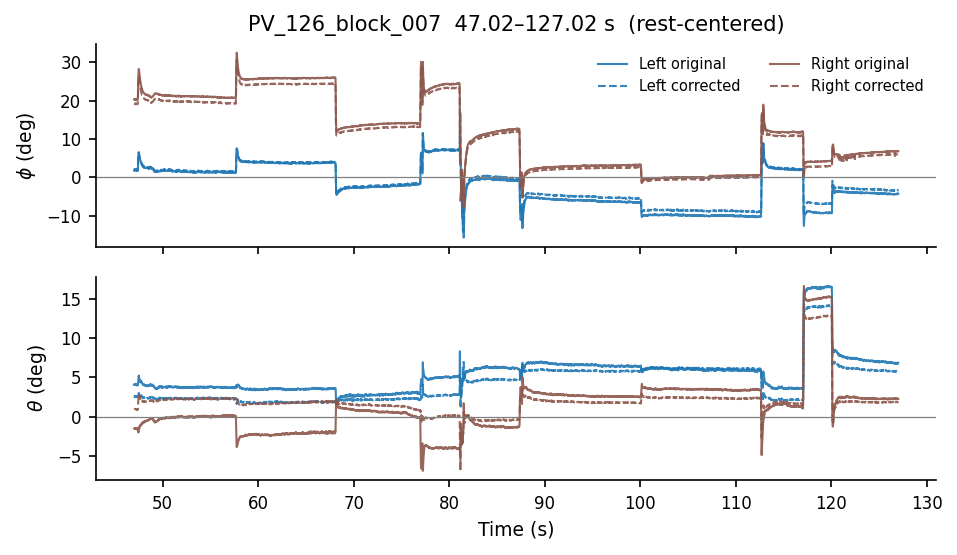

wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/figure_2b_relative_residual.pdf


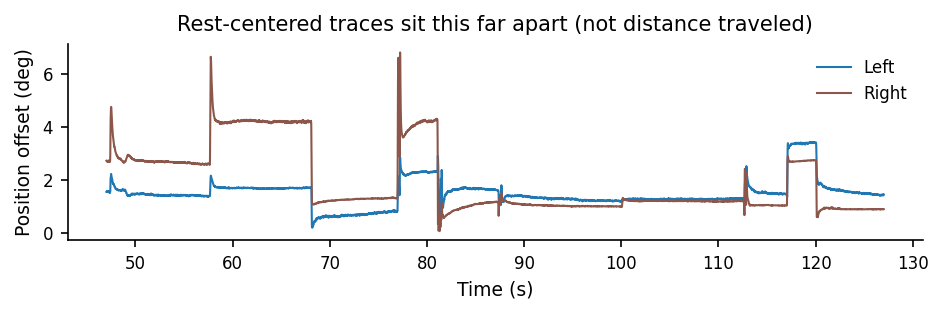

In [7]:
colors = {"L": TRACE_L, "R": TRACE_R}
labels = {"L": "Left", "R": "Right"}

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6.4, 3.8), dpi=150)
for ax, key, ylab in (
    (axes[0], "phi", r"$\phi$ (deg)"),
    (axes[1], "theta", r"$\theta$ (deg)"),
):
    for side in ("L", "R"):
        rec = eyes[side]
        m = rec["mask"]
        t = rec["t_s"][m]
        ax.plot(
            t,
            rec[f"{key}_rel"][m],
            color=colors[side],
            lw=1.0,
            alpha=0.9,
            label=f"{labels[side]} original",
        )
        ax.plot(
            t,
            rec[f"{key}_corr_rel"][m],
            color=colors[side],
            lw=1.0,
            ls="--",
            alpha=0.9,
            label=f"{labels[side]} corrected",
        )
    ax.set_ylabel(ylab, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.axhline(0.0, color="0.5", lw=0.6)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[0].legend(fontsize=7, ncol=2, frameon=False, loc="upper right")
axes[1].set_xlabel("Time (s)", fontsize=9)
axes[0].set_title(f"{BLOCK_KEY}  {WIN_START:.2f}–{WIN_END:.2f} s  (rest-centered)", fontsize=10)
fig.tight_layout()
corr_path = OUT / "figure_2b_kerr_correction.pdf"
fig.savefig(corr_path, bbox_inches="tight")
print("wrote", corr_path)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(6.4, 2.2), dpi=150)
for side in ("L", "R"):
    rec = eyes[side]
    m = rec["mask"]
    ax.plot(
        rec["t_s"][m],
        rec["residual"][m],
        color=colors[side],
        lw=1.0,
        label=labels[side],
    )
ax.set_xlabel("Time (s)", fontsize=9)
ax.set_ylabel("Position offset (deg)", fontsize=9)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8, frameon=False)
ax.set_title("Rest-centered traces sit this far apart (not distance traveled)", fontsize=10)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
resid_path = OUT / "figure_2b_relative_residual.pdf"
fig.savefig(resid_path, bbox_inches="tight")
print("wrote", resid_path)
plt.show()
plt.close(fig)


## 7. Travel distance

Inter-sample angular step on the rest-centered traces, then cumulative path. The scatter should hug the unity line if Kerr barely stretches kinematics; the cumulative traces should nearly overlap.

wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/figure_2b_travel_path.pdf


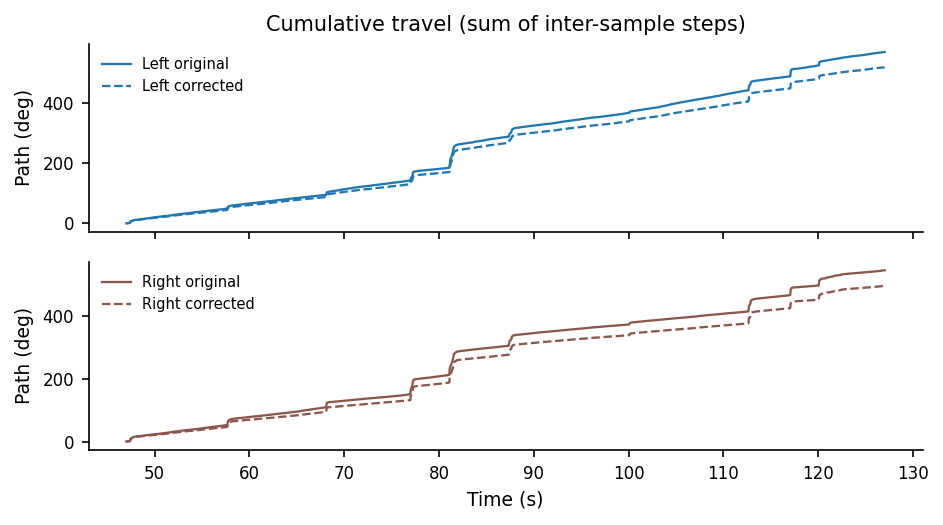

wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/figure_2b_travel_steps.pdf


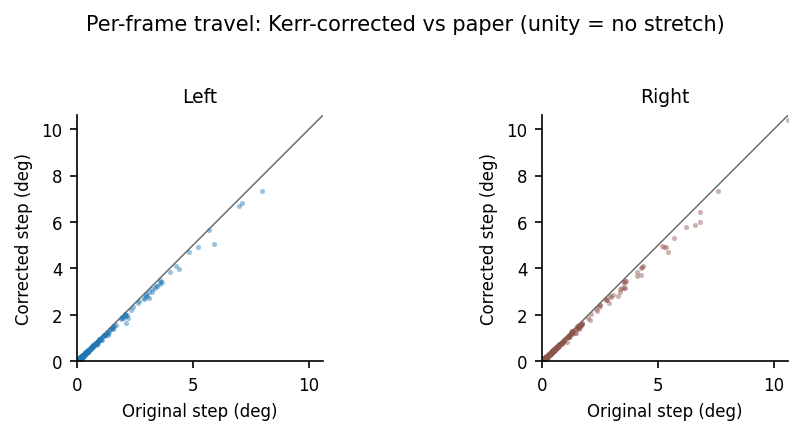

In [8]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(6.4, 3.6), dpi=150)
for ax, side in zip(axes, ("L", "R")):
    rec = eyes[side]
    t = rec["t_step"]
    so = rec["step_orig"]
    sc = rec["step_corr"]
    ok = np.isfinite(so) & np.isfinite(sc) & np.isfinite(t)
    ax.plot(t[ok], np.cumsum(so[ok]), color=colors[side], lw=1.1, label=f"{labels[side]} original")
    ax.plot(t[ok], np.cumsum(sc[ok]), color=colors[side], lw=1.1, ls="--", label=f"{labels[side]} corrected")
    ax.set_ylabel("Path (deg)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, frameon=False, loc="upper left")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[1].set_xlabel("Time (s)", fontsize=9)
axes[0].set_title("Cumulative travel (sum of inter-sample steps)", fontsize=10)
fig.tight_layout()
path_pdf = OUT / "figure_2b_travel_path.pdf"
fig.savefig(path_pdf, bbox_inches="tight")
print("wrote", path_pdf)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8), dpi=150)
lim = 0.0
for ax, side in zip(axes, ("L", "R")):
    rec = eyes[side]
    so = rec["step_orig"]
    sc = rec["step_corr"]
    ok = np.isfinite(so) & np.isfinite(sc)
    ax.scatter(so[ok], sc[ok], s=6, c=colors[side], alpha=0.45, linewidths=0)
    mx = float(np.nanmax(np.concatenate([so[ok], sc[ok]]))) if np.any(ok) else 1.0
    lim = max(lim, mx)
    ax.set_title(labels[side], fontsize=9)
    ax.set_xlabel("Original step (deg)", fontsize=8)
    ax.set_ylabel("Corrected step (deg)", fontsize=8)
    ax.tick_params(labelsize=8)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
for ax in axes:
    ax.plot([0, lim], [0, lim], color="0.4", lw=0.7, zorder=0)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("Per-frame travel: Kerr-corrected vs paper (unity = no stretch)", fontsize=10, y=1.02)
fig.tight_layout()
step_pdf = OUT / "figure_2b_travel_steps.pdf"
fig.savefig(step_pdf, bbox_inches="tight")
print("wrote", step_pdf)
plt.show()
plt.close(fig)


## 8. Component residual histograms (full block)

Euclidean `hypot(dphi, dtheta)` drops sign and folds both axes into a positive magnitude, which inflates how large the error looks. Here each sample is simply:

`dphi = phi_corr_rel - phi_rel`

`dtheta = theta_corr_rel - theta_rel`

on the rest-centered traces, **all frames** of the same block as the traces. The histogram mean is the bias on that axis. The error signal is **mean +/- SEM**, where `SEM = std / sqrt(n)`. The std is the width of the cloud, not the uncertainty on the mean.

The 2D panel keeps directionality: each frame is a vector `(dphi, dtheta)`. The mean vector is the component-wise (vector-space) average -- no hypot. A 1-sigma covariance ellipse shows how the two residuals co-vary.


L phi: n=120385  mean=-0.612 +/- 0.006 deg (SEM)  std=1.957 deg
L theta: n=120385  mean=+0.408 +/- 0.012 deg (SEM)  std=4.005 deg
R phi: n=114688  mean=-0.006 +/- 0.005 deg (SEM)  std=1.576 deg
R theta: n=114688  mean=+0.152 +/- 0.006 deg (SEM)  std=2.199 deg


wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/figure_2b_component_error_hist.pdf


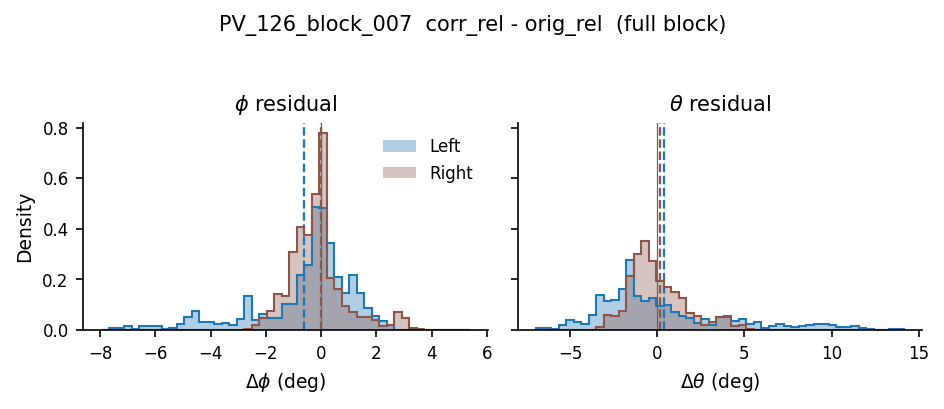

wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/figure_2b_component_error_2d.pdf


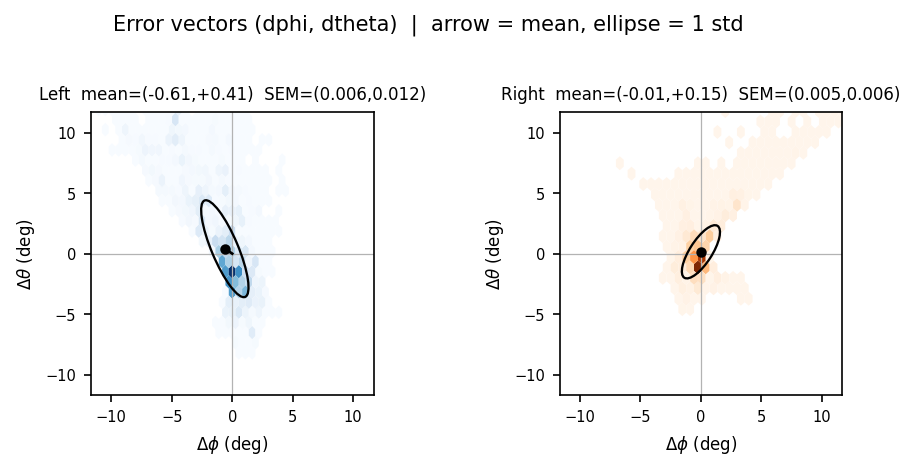

eye  axis      n  mean_deg  std_deg  sem_deg  mean_minus_sem_deg  mean_plus_sem_deg
  L   phi 120385   -0.6116    1.957 0.005641             -0.6173             -0.606
  L theta 120385    0.4081    4.005  0.01154              0.3966             0.4197
  R   phi 114688 -0.006284    1.576 0.004654            -0.01094          -0.001631
  R theta 114688    0.1521    2.199 0.006494              0.1456             0.1586
wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/figure_2b_component_error.csv


In [9]:
from matplotlib.patches import Ellipse

def mean_sem(x: np.ndarray) -> tuple[float, float, float, int]:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = int(x.size)
    if n < 2:
        return float("nan"), float("nan"), float("nan"), n
    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=1))
    sem = sd / np.sqrt(n)
    return mu, sd, sem, n


def cov_ellipse(ax, xs, ys, color, nstd: float = 1.0) -> None:
    pts = np.column_stack([xs, ys])
    pts = pts[np.isfinite(pts).all(axis=1)]
    if pts.shape[0] < 3:
        return
    cov = np.cov(pts, rowvar=False)
    evals, evecs = np.linalg.eigh(cov)
    order = evals.argsort()[::-1]
    evals, evecs = evals[order], evecs[:, order]
    theta = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))
    w, h = 2.0 * nstd * np.sqrt(np.maximum(evals, 0.0))
    ell = Ellipse(
        xy=(float(np.mean(pts[:, 0])), float(np.mean(pts[:, 1]))),
        width=w,
        height=h,
        angle=theta,
        facecolor="none",
        edgecolor=color,
        lw=1.1,
        zorder=4,
    )
    ax.add_patch(ell)


rows = []
residuals = {}
for side in ("L", "R"):
    rec = eyes[side]
    dphi = rec["phi_corr_rel"] - rec["phi_rel"]
    dth = rec["theta_corr_rel"] - rec["theta_rel"]
    ok = np.isfinite(dphi) & np.isfinite(dth)
    dphi, dth = dphi[ok], dth[ok]
    residuals[side] = (dphi, dth)
    for axis_name, arr in (("phi", dphi), ("theta", dth)):
        mu, sd, sem, n = mean_sem(arr)
        rows.append(
            {
                "eye": side,
                "axis": axis_name,
                "n": n,
                "mean_deg": mu,
                "std_deg": sd,
                "sem_deg": sem,
                "mean_minus_sem_deg": mu - sem,
                "mean_plus_sem_deg": mu + sem,
            }
        )
        print(
            f"{side} {axis_name}: n={n}  mean={mu:+.3f} +/- {sem:.3f} deg (SEM)  "
            f"std={sd:.3f} deg"
        )

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.6), dpi=150, sharey=True)
for ax, axis_name, xlab in (
    (axes[0], "phi", r"$\Delta\phi$ (deg)"),
    (axes[1], "theta", r"$\Delta\theta$ (deg)"),
):
    stacked = np.concatenate([residuals[s][0 if axis_name == "phi" else 1] for s in ("L", "R")])
    lo, hi = np.percentile(stacked, [0.5, 99.5])
    span = max(hi - lo, 0.2)
    bins = np.linspace(lo - 0.05 * span, hi + 0.05 * span, 50)
    for side in ("L", "R"):
        arr = residuals[side][0 if axis_name == "phi" else 1]
        ax.hist(
            arr,
            bins=bins,
            density=True,
            histtype="stepfilled",
            alpha=0.35,
            color=colors[side],
            label=labels[side],
        )
        ax.hist(arr, bins=bins, density=True, histtype="step", color=colors[side], lw=1.0)
        mu, sd, sem, n = mean_sem(arr)
        ax.axvline(mu, color=colors[side], lw=1.1, ls="--")
        ax.axvspan(mu - sem, mu + sem, color=colors[side], alpha=0.12, lw=0)
    ax.set_xlabel(xlab, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.axvline(0.0, color="0.4", lw=0.6)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel("Density", fontsize=9)
axes[0].legend(fontsize=8, frameon=False)
axes[0].set_title(r"$\phi$ residual", fontsize=10)
axes[1].set_title(r"$\theta$ residual", fontsize=10)
fig.suptitle(f"{BLOCK_KEY}  corr_rel - orig_rel  (full block)", fontsize=10, y=1.03)
fig.tight_layout()
hist_pdf = OUT / "figure_2b_component_error_hist.pdf"
fig.savefig(hist_pdf, bbox_inches="tight")
print("wrote", hist_pdf)
plt.show()
plt.close(fig)

# ---- Make the X-Y scale equal for the Error vectors plot ----
fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.0), dpi=150)
lims = []  # Collect limits for both axes to enforce global equal scale
for ax, side in zip(axes, ("L", "R")):
    dphi, dth = residuals[side]
    ax.hexbin(dphi, dth, gridsize=40, cmap="Blues" if side == "L" else "Oranges", mincnt=1, linewidths=0)
    mu_p, _, sem_p, _ = mean_sem(dphi)
    mu_t, _, sem_t, _ = mean_sem(dth)
    ax.axhline(0.0, color="0.7", lw=0.6)
    ax.axvline(0.0, color="0.7", lw=0.6)
    ax.plot([0, mu_p], [0, mu_t], color="black", lw=1.3, zorder=5)
    ax.plot(mu_p, mu_t, "o", color="black", ms=4, zorder=6)
    cov_ellipse(ax, dphi, dth, color="black", nstd=1.0)
    ax.set_title(
        f"{labels[side]}  mean=({mu_p:+.2f},{mu_t:+.2f})  SEM=({sem_p:.3f},{sem_t:.3f})",
        fontsize=8,
    )
    ax.set_xlabel(r"$\Delta\phi$ (deg)", fontsize=8)
    ax.set_ylabel(r"$\Delta\theta$ (deg)", fontsize=8)
    ax.tick_params(labelsize=7)
    # Compute symmetric limits over both axes using the 99th percentile of absolute values (for both dphi and dth)
    axis_lim = max(
        float(np.percentile(np.abs(dphi), 99)),
        float(np.percentile(np.abs(dth), 99)),
        0.05
    )
    lims.append(axis_lim)
# Set both axes to use the same symmetric [-lim, +lim] range
final_lim = max(lims)
for ax in axes:
    ax.set_xlim(-final_lim, final_lim)
    ax.set_ylim(-final_lim, final_lim)
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("Error vectors (dphi, dtheta)  |  arrow = mean, ellipse = 1 std", fontsize=10, y=1.02)
fig.tight_layout()
vec_pdf = OUT / "figure_2b_component_error_2d.pdf"
fig.savefig(vec_pdf, bbox_inches="tight")
print("wrote", vec_pdf)
plt.show()
plt.close(fig)

comp_df = pd.DataFrame(rows)
comp_csv = OUT / "figure_2b_component_error.csv"
comp_df.to_csv(comp_csv, index=False)
print(comp_df.to_string(index=False, float_format=lambda x: f"{x:.4g}"))
print("wrote", comp_csv)


## 9. All ready paper blocks

Same residual as section 8 (`Δ = corr_rel − orig_rel` after a full-block nanmedian), now on **every paper-registry block that is ready**, not one block per animal.

Readiness is the analogue of the jitter QC table: the block must be mounted, have `analysis/`, and carry **both** `left_eye_data*degrees_raw_verified*.csv` and `right_eye_data*degrees_raw_verified*.csv` with `k_phi` / `k_theta` and enough finite samples. Non-verified eye CSVs are not used. Untick a row (or add its `block_key` to `BLOCK_SKIP`) to drop it.

Requires the interpolator from section 3. Rest geometry can differ by headmount **and** by remount date, so pooling extra blocks of the same animal increases occupancy resolution without pretending PV_126 is the cohort.


In [10]:
# Keys to force-exclude even if files are present (same role as unticking a jitter pool row).
BLOCK_SKIP: set[str] = set()
MIN_FINITE_FRAMES = 100
ANGLE_COLS = ("k_phi", "k_theta")
VERIFIED_GLOB = "{side}_eye_data*degrees_raw_verified*.csv"

COHORT_COLORS = {"L": TRACE_L, "R": TRACE_R}
COHORT_LABELS = {"L": "Left", "R": "Right"}


def _verified_csv(analysis: Path, side: str) -> Path | None:
    hits = sorted(analysis.glob(VERIFIED_GLOB.format(side=side)))
    if not hits:
        return None
    return max(hits, key=lambda p: p.stat().st_mtime)


def _csv_angle_status(path: Path | None) -> tuple[bool, int, str]:
    if path is None or not path.is_file():
        return False, 0, "missing degrees_raw_verified.csv"
    try:
        header = set(pd.read_csv(path, nrows=0).columns)
    except Exception as exc:
        return False, 0, f"unreadable header ({exc})"
    missing = [c for c in ANGLE_COLS if c not in header]
    if missing:
        return False, 0, f"missing columns {missing}"
    try:
        phi = pd.to_numeric(pd.read_csv(path, usecols=["k_phi"])["k_phi"], errors="coerce")
    except Exception as exc:
        return False, 0, f"unreadable k_phi ({exc})"
    n = int(np.isfinite(phi.to_numpy(dtype=float)).sum())
    if n < MIN_FINITE_FRAMES:
        return False, n, f"only {n} finite k_phi (need ≥{MIN_FINITE_FRAMES})"
    return True, n, "ok"


def assess_kerr_block(spec) -> dict:
    row = {
        "animal": spec.animal,
        "block_key": spec.block_key,
        "block_num": spec.block_num,
        "mounted": spec.block_path.exists(),
        "analysis_dir": spec.analysis_path.is_dir(),
        "left_csv": "",
        "right_csv": "",
        "n_left": 0,
        "n_right": 0,
        "ready": False,
        "skip": spec.block_key in BLOCK_SKIP,
        "reason": "",
        "block_path": str(spec.block_path),
    }
    if not row["mounted"]:
        row["reason"] = "block path not mounted"
        return row
    if not row["analysis_dir"]:
        row["reason"] = "no analysis/ folder"
        return row
    left = _verified_csv(spec.analysis_path, "left")
    right = _verified_csv(spec.analysis_path, "right")
    row["left_csv"] = left.name if left else ""
    row["right_csv"] = right.name if right else ""
    left_ok, n_l, left_why = _csv_angle_status(left)
    right_ok, n_r, right_why = _csv_angle_status(right)
    row["n_left"] = n_l
    row["n_right"] = n_r
    if not left_ok:
        row["reason"] = f"left: {left_why}"
        return row
    if not right_ok:
        row["reason"] = f"right: {right_why}"
        return row
    if row["skip"]:
        row["reason"] = "in BLOCK_SKIP"
        return row
    row["ready"] = True
    row["reason"] = "ok"
    return row


registry_specs = read_paper_registry(REGISTRY)
readiness_rows = [assess_kerr_block(s) for s in registry_specs]
readiness_df = pd.DataFrame(readiness_rows)
readiness_csv = OUT / "cohort_block_readiness.csv"
readiness_df.to_csv(readiness_csv, index=False)

n_reg = len(readiness_df)
n_ready = int(readiness_df["ready"].sum())
print(f"paper registry: {n_reg} block(s), {n_ready} ready for Kerr residuals")
print(readiness_df.drop(columns=["block_path"]).to_string(index=False))
print("wrote", readiness_csv)
if n_ready == 0:
    print("No ready blocks — mount the lab volume / export degrees_raw_verified CSVs.")

ready_specs = [s for s, r in zip(registry_specs, readiness_rows) if r["ready"]]
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None

block_checks: dict[str, object] = {}
if widgets is not None and ready_specs:
    groups = []
    by_animal: dict[str, list] = {}
    for spec in ready_specs:
        by_animal.setdefault(spec.animal, []).append(spec)
    for animal, specs in by_animal.items():
        boxes = []
        for spec in specs:
            box = widgets.Checkbox(
                value=True,
                description=spec.block_key,
                indent=False,
                layout=widgets.Layout(width="280px"),
            )
            block_checks[spec.block_key] = box
            boxes.append(box)
        groups.append(widgets.VBox([widgets.HTML(f"<b>{animal}</b> ({len(specs)} ready)")] + boxes))
    display(widgets.HTML("<b>Include in sections 9–10</b> (untick to drop; defaults = all ready)"))
    display(widgets.HBox(groups, layout=widgets.Layout(flex_flow="row wrap")))
elif ready_specs:
    print("ipywidgets not available — using every ready block.")
    print("selected:", ", ".join(s.block_key for s in ready_specs))


def selected_ready_specs():
    if not block_checks:
        return list(ready_specs)
    return [s for s in ready_specs if getattr(block_checks[s.block_key], "value", True)]


paper registry: 23 block(s), 23 ready for Kerr residuals
animal        block_key block_num  mounted  analysis_dir                               left_csv                               right_csv  n_left  n_right  ready  skip reason
PV_106 PV_106_block_008       008     True          True left_eye_data_degrees_raw_verified.csv right_eye_data_degrees_raw_verified.csv   52088    53467   True False     ok
PV_106 PV_106_block_009       009     True          True left_eye_data_degrees_raw_verified.csv right_eye_data_degrees_raw_verified.csv   49552    50909   True False     ok
PV_106 PV_106_block_010       010     True          True left_eye_data_degrees_raw_verified.csv right_eye_data_degrees_raw_verified.csv   47864    47199   True False     ok
PV_106 PV_106_block_011       011     True          True left_eye_data_degrees_raw_verified.csv right_eye_data_degrees_raw_verified.csv  108836   118384   True False     ok
PV_106 PV_106_block_012       012     True          True left_eye_data_degrees

HTML(value='<b>Include in sections 9–10</b> (untick to drop; defaults = all ready)')

## 9b. Residual distributions (all selected blocks)

Lookup stays on **unzeroed** Kerr angles; comparison is rest-centered. Frames from every selected block of an animal are pooled for the histograms (more occupancy, same animal mount family). The CSV is still **one row per block × eye × axis** so remounts stay visible.


computing residuals for 23 / 23 ready block(s)
  PV_106    PV_106_block_008        /Volumes/Data-1/Nimrod/experiments/PV_106/2025_08_06/block_008
  PV_106    PV_106_block_009        /Volumes/Data-1/Nimrod/experiments/PV_106/2025_08_06/block_009
  PV_106    PV_106_block_010        /Volumes/Data-1/Nimrod/experiments/PV_106/2025_08_06/block_010
  PV_106    PV_106_block_011        /Volumes/Data-1/Nimrod/experiments/PV_106/2025_08_06/block_011
  PV_106    PV_106_block_012        /Volumes/Data-1/Nimrod/experiments/PV_106/2025_08_06/block_012
  PV_143    PV_143_block_001        /Volumes/Data-1/Nimrod/experiments/PV_143/2025_08_25/block_001
  PV_143    PV_143_block_002        /Volumes/Data-1/Nimrod/experiments/PV_143/2025_08_25/block_002
  PV_143    PV_143_block_003        /Volumes/Data-1/Nimrod/experiments/PV_143/2025_08_25/block_003
  PV_143    PV_143_block_004        /Volumes/Data-1/Nimrod/experiments/PV_143/2025_08_25/block_004
  PV_62     PV_62_block_024         /Volumes/Data-1/Nimrod/exp


=== PV_106_block_008 ===


L: rest raw (φ,θ)=(-13.586, -43.060)  ecc=45.15°  rest corr=(-14.497, -35.203)  n=52088  lookup-NaN=0
  L phi: n=52088  mean=+0.389 +/- 0.006 deg (SEM)  std=1.313 deg  mean|Δ|=0.824  std|Δ|=1.093
  L theta: n=52088  mean=-0.155 +/- 0.005 deg (SEM)  std=1.223 deg  mean|Δ|=0.973  std|Δ|=0.758
R: rest raw (φ,θ)=(6.654, -42.898)  ecc=43.41°  rest corr=(8.161, -36.511)  n=53467  lookup-NaN=0
  R phi: n=53467  mean=+0.019 +/- 0.002 deg (SEM)  std=0.394 deg  mean|Δ|=0.300  std|Δ|=0.256
  R theta: n=53467  mean=+0.010 +/- 0.002 deg (SEM)  std=0.452 deg  mean|Δ|=0.354  std|Δ|=0.281



=== PV_106_block_009 ===


L: rest raw (φ,θ)=(-17.727, -42.585)  ecc=46.13°  rest corr=(-18.939, -34.290)  n=49552  lookup-NaN=0
  L phi: n=49552  mean=+0.069 +/- 0.003 deg (SEM)  std=0.743 deg  mean|Δ|=0.530  std|Δ|=0.526
  L theta: n=49552  mean=-0.097 +/- 0.005 deg (SEM)  std=1.084 deg  mean|Δ|=0.816  std|Δ|=0.720


...

R: rest raw (φ,θ)=(10.046, -45.477)  ecc=46.57°  rest corr=(12.282, -38.073)  n=38867  lookup-NaN=0
  R phi: n=38867  mean=+0.408 +/- 0.010 deg (SEM)  std=1.927 deg  mean|Δ|=1.347  std|Δ|=1.437
  R theta: n=38867  mean=+0.239 +/- 0.010 deg (SEM)  std=1.946 deg  mean|Δ|=1.414  std|Δ|=1.358



=== PV_57_block_012 ===
L: rest raw (φ,θ)=(-0.024, -32.147)  ecc=32.15°  rest corr=(0.543, -27.463)  n=52982  lookup-NaN=0
  L phi: n=52982  mean=-0.021 +/- 0.001 deg (SEM)  std=0.238 deg  mean|Δ|=0.127  std|Δ|=0.203
  L theta: n=52982  mean=-0.040 +/- 0.003 deg (SEM)  std=0.671 deg  mean|Δ|=0.491  std|Δ|=0.459
R: rest raw (φ,θ)=(10.470, -45.505)  ecc=46.69°  rest corr=(12.944, -38.421)  n=52924  lookup-NaN=0
  R phi: n=52924  mean=-0.126 +/- 0.005 deg (SEM)  std=1.165 deg  mean|Δ|=0.843  std|Δ|=0.814
  R theta: n=52924  mean=+0.213 +/- 0.005 deg (SEM)  std=1.242 deg  mean|Δ|=0.868  std|Δ|=0.913



=== PV_57_block_013 ===


L: rest raw (φ,θ)=(-6.169, -30.766)  ecc=31.38°  rest corr=(-5.634, -26.131)  n=47756  lookup-NaN=0
  L phi: n=47756  mean=-0.138 +/- 0.002 deg (SEM)  std=0.463 deg  mean|Δ|=0.253  std|Δ|=0.412
  L theta: n=47756  mean=+0.229 +/- 0.004 deg (SEM)  std=0.951 deg  mean|Δ|=0.657  std|Δ|=0.724
R: rest raw (φ,θ)=(15.859, -45.985)  ecc=48.64°  rest corr=(19.020, -37.435)  n=48575  lookup-NaN=0
  R phi: n=48575  mean=+0.235 +/- 0.007 deg (SEM)  std=1.652 deg  mean|Δ|=1.224  std|Δ|=1.133
  R theta: n=48575  mean=+0.114 +/- 0.009 deg (SEM)  std=2.046 deg  mean|Δ|=1.522  std|Δ|=1.372

 animal        block_key                                                     block_path eye  axis  rest_phi_deg  rest_theta_deg  rest_ecc_deg  rest_phi_corr_deg  rest_theta_corr_deg  n_lookup_nan      n   mean_deg  std_deg  sem_deg  n_abs  mean_abs_deg  std_abs_deg  median_abs_deg  p95_abs_deg
PV_106 PV_106_block_008 /Volumes/Data-1/Nimrod/experiments/PV_106/2025_08_06/block_008   L   phi        -13.59          -43.

wrote /Users/nimi/Projects/PETS/development/kerr_relative_error/outputs/cohort_component_error_hist.pdf


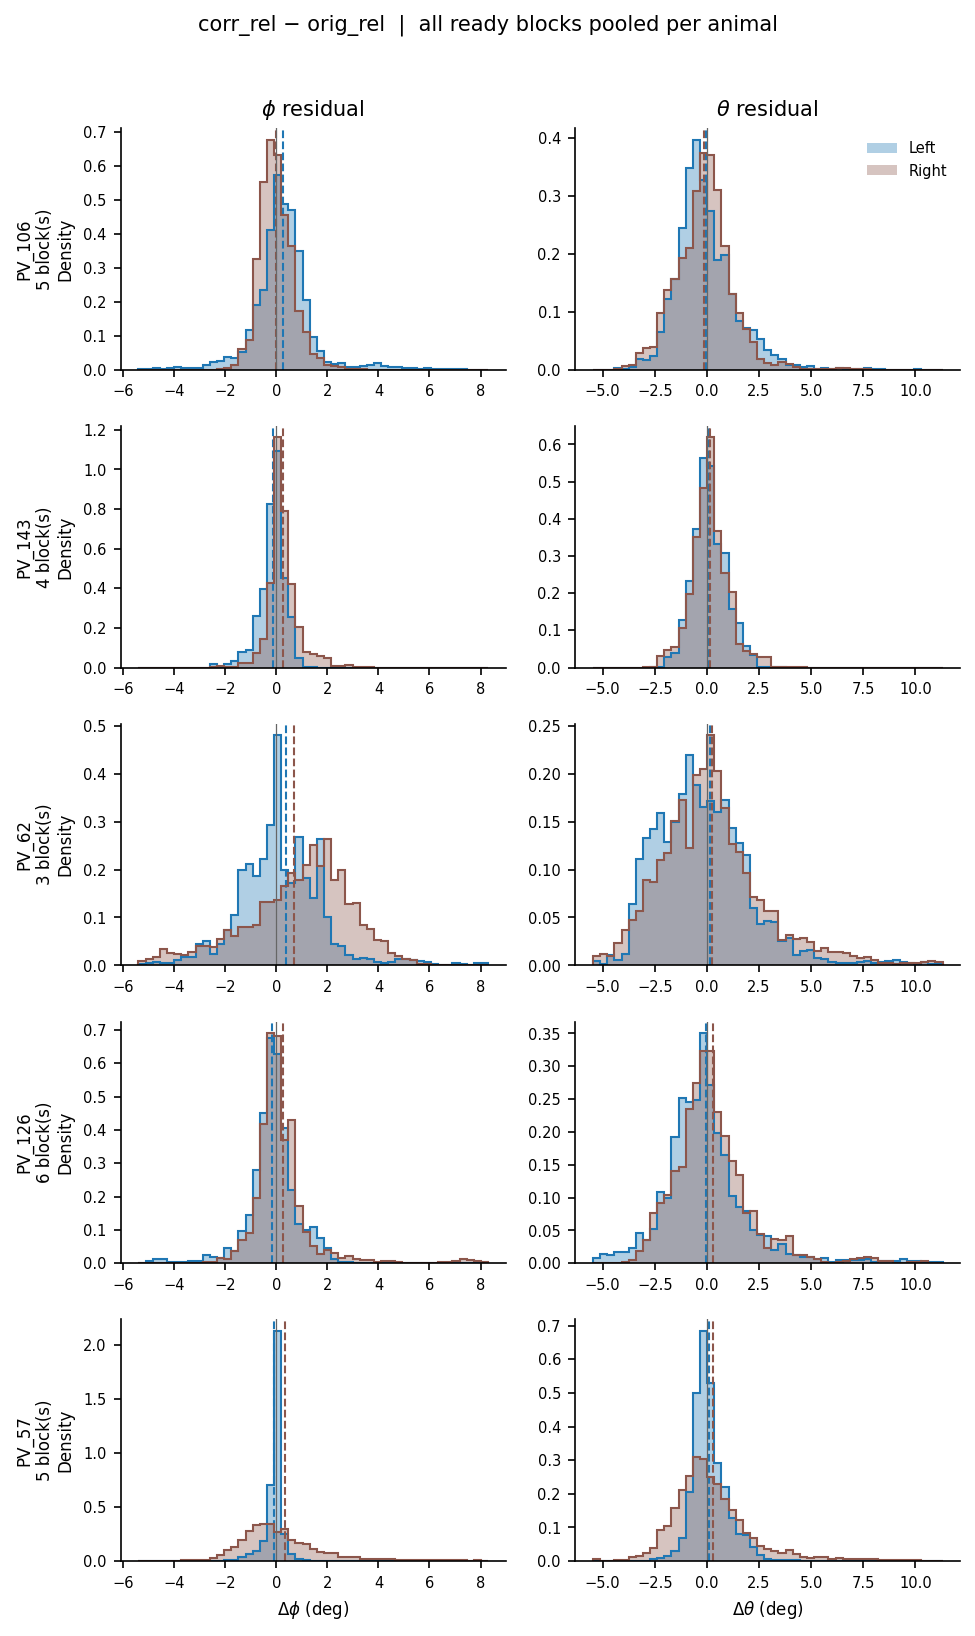

In [11]:
def _signed_stats(x: np.ndarray) -> dict:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = int(x.size)
    if n < 2:
        return {"n": n, "mean_deg": np.nan, "std_deg": np.nan, "sem_deg": np.nan}
    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=1))
    return {"n": n, "mean_deg": mu, "std_deg": sd, "sem_deg": sd / np.sqrt(n)}


def _abs_stats(x: np.ndarray) -> dict:
    x = np.abs(np.asarray(x, dtype=float))
    x = x[np.isfinite(x)]
    n = int(x.size)
    if n < 2:
        return {
            "n_abs": n,
            "mean_abs_deg": np.nan,
            "std_abs_deg": np.nan,
            "median_abs_deg": np.nan,
            "p95_abs_deg": np.nan,
        }
    return {
        "n_abs": n,
        "mean_abs_deg": float(np.mean(x)),
        "std_abs_deg": float(np.std(x, ddof=1)),
        "median_abs_deg": float(np.median(x)),
        "p95_abs_deg": float(np.percentile(x, 95)),
    }


def relative_component_residuals(df: pd.DataFrame) -> dict:
    """Full-block Δφ/Δθ after Kerr lookup on unzeroed angles and rest-zero of both traces."""
    phi = pd.to_numeric(df["k_phi"], errors="coerce").to_numpy(dtype=float)
    theta = pd.to_numeric(df["k_theta"], errors="coerce").to_numpy(dtype=float)
    err_phi, err_theta = lookup_kerr_error(phi, theta)
    phi_rel, med_phi = recenter_series(phi)
    theta_rel, med_theta = recenter_series(theta)
    phi_corr_rel, med_phi_corr = recenter_series(phi - err_phi)
    theta_corr_rel, med_theta_corr = recenter_series(theta - err_theta)
    dphi = phi_corr_rel - phi_rel
    dtheta = theta_corr_rel - theta_rel
    ok = np.isfinite(dphi) & np.isfinite(dtheta)
    n_lookup_nan = int(np.sum(np.isfinite(phi) & np.isfinite(theta) & ~np.isfinite(err_phi)))
    return {
        "dphi": dphi[ok],
        "dtheta": dtheta[ok],
        "med_phi": med_phi,
        "med_theta": med_theta,
        "med_phi_corr": med_phi_corr,
        "med_theta_corr": med_theta_corr,
        "rest_ecc_deg": float(np.hypot(med_phi, med_theta)) if np.isfinite(med_phi) else np.nan,
        "n_lookup_nan": n_lookup_nan,
    }


def _load_verified_eyes(spec) -> tuple[pd.DataFrame, pd.DataFrame]:
    left_path = _verified_csv(spec.analysis_path, "left")
    right_path = _verified_csv(spec.analysis_path, "right")
    if left_path is None or right_path is None:
        raise FileNotFoundError(f"{spec.block_key}: degrees_raw_verified CSV missing at compute time")
    return pd.read_csv(left_path), pd.read_csv(right_path)


chosen_specs = selected_ready_specs()
print(f"computing residuals for {len(chosen_specs)} / {len(ready_specs)} ready block(s)")
for spec in chosen_specs:
    print(f"  {spec.animal:8s}  {spec.block_key:22s}  {spec.block_path}")

block_residuals: dict[str, dict] = {}
per_block_rows: list[dict] = []

for spec in chosen_specs:
    try:
        left_df, right_df = _load_verified_eyes(spec)
    except (FileNotFoundError, OSError) as exc:
        print(f"{spec.block_key}: skip ({exc})")
        continue
    rec_by_eye = {"spec": spec}
    print(f"\n=== {spec.block_key} ===")
    usable = True
    for side, df in (("L", left_df), ("R", right_df)):
        rec = relative_component_residuals(df)
        rec_by_eye[side] = rec
        if rec["dphi"].size < MIN_FINITE_FRAMES:
            print(f"{side}: only {rec['dphi'].size} finite residuals — skip block")
            usable = False
            break
        mag = np.hypot(rec["dphi"], rec["dtheta"])
        print(
            f"{side}: rest raw (φ,θ)=({rec['med_phi']:.3f}, {rec['med_theta']:.3f})  "
            f"ecc={rec['rest_ecc_deg']:.2f}°  rest corr=({rec['med_phi_corr']:.3f}, {rec['med_theta_corr']:.3f})  "
            f"n={rec['dphi'].size}  lookup-NaN={rec['n_lookup_nan']}"
        )
        for axis_name, arr in (("phi", rec["dphi"]), ("theta", rec["dtheta"]), ("hypot", mag)):
            signed = _signed_stats(arr)
            ab = _abs_stats(arr)
            if axis_name != "hypot":
                print(
                    f"  {side} {axis_name}: n={signed['n']}  "
                    f"mean={signed['mean_deg']:+.3f} +/- {signed['sem_deg']:.3f} deg (SEM)  "
                    f"std={signed['std_deg']:.3f} deg  "
                    f"mean|Δ|={ab['mean_abs_deg']:.3f}  std|Δ|={ab['std_abs_deg']:.3f}"
                )
            per_block_rows.append(
                {
                    "animal": spec.animal,
                    "block_key": spec.block_key,
                    "block_path": str(spec.block_path),
                    "eye": side,
                    "axis": axis_name,
                    "rest_phi_deg": rec["med_phi"],
                    "rest_theta_deg": rec["med_theta"],
                    "rest_ecc_deg": rec["rest_ecc_deg"],
                    "rest_phi_corr_deg": rec["med_phi_corr"],
                    "rest_theta_corr_deg": rec["med_theta_corr"],
                    "n_lookup_nan": rec["n_lookup_nan"],
                    **signed,
                    **ab,
                }
            )
    if usable:
        block_residuals[spec.block_key] = rec_by_eye

per_block_df = pd.DataFrame(per_block_rows)
per_block_csv = OUT / "cohort_component_error_per_block.csv"
per_block_df.to_csv(per_block_csv, index=False)
# Keep the old filename as a copy so earlier notes still resolve.
per_animal_df = per_block_df.copy()
per_animal_csv = OUT / "cohort_component_error_per_animal.csv"
per_animal_df.to_csv(per_animal_csv, index=False)
print("\n", per_block_df.to_string(index=False, float_format=lambda x: f"{x:.4g}"))
print("wrote", per_block_csv)
print("wrote", per_animal_csv)

animal_residuals: dict[str, dict] = {}
for recs in block_residuals.values():
    animal = recs["spec"].animal
    slot = animal_residuals.setdefault(
        animal,
        {"blocks": [], "L": {"dphi": [], "dtheta": []}, "R": {"dphi": [], "dtheta": []}},
    )
    slot["blocks"].append(recs["spec"])
    for side in ("L", "R"):
        slot[side]["dphi"].append(recs[side]["dphi"])
        slot[side]["dtheta"].append(recs[side]["dtheta"])
for animal, slot in animal_residuals.items():
    for side in ("L", "R"):
        slot[side]["dphi"] = np.concatenate(slot[side]["dphi"]) if slot[side]["dphi"] else np.array([])
        slot[side]["dtheta"] = np.concatenate(slot[side]["dtheta"]) if slot[side]["dtheta"] else np.array([])

animals = list(animal_residuals)
if not animals:
    print("No animals loaded — mount the lab volume and re-run the readiness cell.")
else:
    fig, axes = plt.subplots(
        len(animals), 2, figsize=(6.6, 2.15 * len(animals)), dpi=150, squeeze=False
    )
    stacked = {"phi": [], "theta": []}
    for recs in animal_residuals.values():
        for side in ("L", "R"):
            stacked["phi"].append(recs[side]["dphi"])
            stacked["theta"].append(recs[side]["dtheta"])
    bins = {}
    for axis_name in ("phi", "theta"):
        all_ax = np.concatenate(stacked[axis_name]) if stacked[axis_name] else np.array([0.0])
        lo, hi = np.percentile(all_ax, [0.5, 99.5])
        span = max(hi - lo, 0.2)
        bins[axis_name] = np.linspace(lo - 0.05 * span, hi + 0.05 * span, 50)
    axis_title = {"phi": r"$\phi$ residual", "theta": r"$\theta$ residual"}
    axis_xlab = {"phi": r"$\Delta\phi$ (deg)", "theta": r"$\Delta\theta$ (deg)"}
    for row, animal in enumerate(animals):
        recs = animal_residuals[animal]
        n_blocks = len(recs["blocks"])
        for col, axis_name in enumerate(("phi", "theta")):
            ax = axes[row, col]
            key = "dphi" if axis_name == "phi" else "dtheta"
            for side in ("L", "R"):
                arr = recs[side][key]
                ax.hist(
                    arr,
                    bins=bins[axis_name],
                    density=True,
                    histtype="stepfilled",
                    alpha=0.35,
                    color=COHORT_COLORS[side],
                    label=COHORT_LABELS[side],
                )
                ax.hist(arr, bins=bins[axis_name], density=True, histtype="step", color=COHORT_COLORS[side], lw=1.0)
                stats = _signed_stats(arr)
                ax.axvline(stats["mean_deg"], color=COHORT_COLORS[side], lw=1.0, ls="--")
            ax.axvline(0.0, color="0.4", lw=0.6)
            ax.tick_params(labelsize=7)
            for spine in ("top", "right"):
                ax.spines[spine].set_visible(False)
            if row == 0:
                ax.set_title(axis_title[axis_name], fontsize=10)
            if row == len(animals) - 1:
                ax.set_xlabel(axis_xlab[axis_name], fontsize=8)
            if col == 0:
                ax.set_ylabel(f"{animal}\n{n_blocks} block(s)\nDensity", fontsize=8)
            if row == 0 and col == 1:
                ax.legend(fontsize=7, frameon=False)
    fig.suptitle("corr_rel − orig_rel  |  all ready blocks pooled per animal", fontsize=10, y=1.01)
    fig.tight_layout()
    cohort_hist_pdf = OUT / "cohort_component_error_hist.pdf"
    fig.savefig(cohort_hist_pdf, bbox_inches="tight")
    print("wrote", cohort_hist_pdf)
    plt.show()
    plt.close(fig)


## 10. Across-animal |Δ| summary

**Animal** is still the sampling unit. Each animal's number is the unweighted mean of its **ready blocks** (a long recording does not outvote a remount). Block-level points are overplotted so within-animal spread is visible.

`mean |Δ|` is the typical per-frame shift after rest-zero. `std |Δ|` is the width of that absolute distribution. Across-animal mean ± SD of the animal-level `mean |Δ|` is the cohort range to quote.


Per block  (mean |Δ|  /  std |Δ|  in deg)


                        mean_abs_deg                               std_abs_deg                              
eye                                L                 R                       L                 R            
axis                           hypot   phi theta hypot   phi theta       hypot   phi theta hypot   phi theta
animal block_key                                                                                            
PV_106 PV_106_block_008        1.392 0.824 0.973 0.483 0.300 0.354       1.208 1.093 0.758 0.356 0.256 0.281
       PV_106_block_009        1.035 0.530 0.816 1.228 0.411 1.085       0.818 0.526 0.720 0.935 0.335 0.961
       PV_106_block_010        1.290 0.883 0.844 0.940 0.542 0.726       1.380 1.231 0.751 0.625 0.396 0.543
       PV_106_block_011        1.569 0.763 1.297 1.320 0.595 1.127       1.290 0.777 1.122 0.877 0.427 0.840
       PV_106_block_012        1.612 0.975 1.172 1.516 0.528 1.344       1.468 1.066 1.137 1.112 0.510 1.091
PV_126 PV_126_block

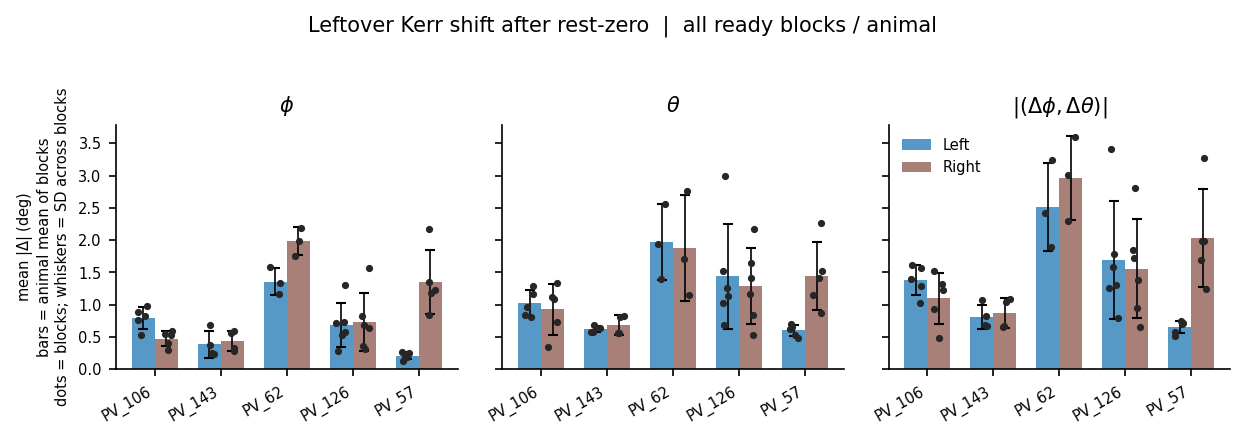

In [12]:
if per_block_df.empty:
    raise RuntimeError("Section 9b produced no rows. Fix readiness (verified CSVs) and re-run.")

axis_order = ("phi", "theta", "hypot")
eye_order = ("L", "R")


def _across_animal_stats(g: pd.DataFrame) -> dict:
    mean_abs = g["mean_abs_deg"].to_numpy(dtype=float)
    std_abs = g["std_abs_deg"].to_numpy(dtype=float)
    n = int(np.sum(np.isfinite(mean_abs)))

    def _mean_sd(x: np.ndarray) -> tuple[float, float]:
        x = x[np.isfinite(x)]
        if x.size == 0:
            return np.nan, np.nan
        if x.size == 1:
            return float(x[0]), np.nan
        return float(np.mean(x)), float(np.std(x, ddof=1))

    mu_m, sd_m = _mean_sd(mean_abs)
    mu_s, sd_s = _mean_sd(std_abs)
    return {
        "n_animals": n,
        "mean_of_mean_abs_deg": mu_m,
        "std_of_mean_abs_deg": sd_m,
        "min_mean_abs_deg": float(np.nanmin(mean_abs)) if n else np.nan,
        "max_mean_abs_deg": float(np.nanmax(mean_abs)) if n else np.nan,
        "mean_of_std_abs_deg": mu_s,
        "std_of_std_abs_deg": sd_s,
        "min_std_abs_deg": float(np.nanmin(std_abs)) if n else np.nan,
        "max_std_abs_deg": float(np.nanmax(std_abs)) if n else np.nan,
    }


# One row per block × eye=both (L/R frames concatenated), then animal = mean of those blocks.
both_block_rows = []
for block_key, recs in block_residuals.items():
    spec = recs["spec"]
    dphi = np.concatenate([recs["L"]["dphi"], recs["R"]["dphi"]])
    dth = np.concatenate([recs["L"]["dtheta"], recs["R"]["dtheta"]])
    pooled = {"phi": dphi, "theta": dth, "hypot": np.hypot(dphi, dth)}
    for axis_name, arr in pooled.items():
        ab = _abs_stats(arr)
        both_block_rows.append(
            {
                "animal": spec.animal,
                "block_key": block_key,
                "eye": "both",
                "axis": axis_name,
                "mean_abs_deg": ab["mean_abs_deg"],
                "std_abs_deg": ab["std_abs_deg"],
            }
        )
both_block_df = pd.DataFrame(both_block_rows)

animal_rows = []
block_src = pd.concat(
    [
        per_block_df[per_block_df["axis"].isin(axis_order)][["animal", "block_key", "eye", "axis", "mean_abs_deg", "std_abs_deg"]],
        both_block_df,
    ],
    ignore_index=True,
)
for (animal, eye, axis_name), g in block_src.groupby(["animal", "eye", "axis"], sort=False):
    animal_rows.append(
        {
            "animal": animal,
            "eye": eye,
            "axis": axis_name,
            "n_blocks": int(g["block_key"].nunique()),
            "mean_abs_deg": float(g["mean_abs_deg"].mean()),
            "std_abs_deg": float(g["std_abs_deg"].mean()),
            "std_of_block_mean_abs_deg": float(g["mean_abs_deg"].std(ddof=1)) if len(g) > 1 else np.nan,
        }
    )
per_animal_level_df = pd.DataFrame(animal_rows)

across_rows = []
for eye in (*eye_order, "both"):
    for axis_name in axis_order:
        g = per_animal_level_df[(per_animal_level_df["eye"] == eye) & (per_animal_level_df["axis"] == axis_name)]
        across_rows.append({"eye": eye, "axis": axis_name, **_across_animal_stats(g)})

across_df = pd.DataFrame(across_rows)
across_csv = OUT / "cohort_component_error_across_animals.csv"
across_df.to_csv(across_csv, index=False)

print("Per block  (mean |Δ|  /  std |Δ|  in deg)")
show = per_block_df.pivot_table(
    index=["animal", "block_key"],
    columns=["eye", "axis"],
    values=["mean_abs_deg", "std_abs_deg"],
)
print(show.to_string(float_format=lambda x: f"{x:.3f}"))

print("\nPer animal  (unweighted mean of that animal's ready blocks)")
show_an = per_animal_level_df.pivot_table(
    index=["animal", "n_blocks"],
    columns=["eye", "axis"],
    values="mean_abs_deg",
)
print(show_an.to_string(float_format=lambda x: f"{x:.3f}"))

print("\nAcross animals  (animal = unit)")
print(across_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("wrote", across_csv)

print("\nCohort one-liners (eye-pooled, animal SD):")
for axis_name in axis_order:
    row = across_df[(across_df["eye"] == "both") & (across_df["axis"] == axis_name)].iloc[0]
    print(
        f"  {axis_name}: mean|Δ| = {row['mean_of_mean_abs_deg']:.2f} ± {row['std_of_mean_abs_deg']:.2f}° "
        f"(range {row['min_mean_abs_deg']:.2f}–{row['max_mean_abs_deg']:.2f}°); "
        f"std|Δ| = {row['mean_of_std_abs_deg']:.2f} ± {row['std_of_std_abs_deg']:.2f}° "
        f"(n={int(row['n_animals'])} animals)"
    )

animals = [a for a in per_animal_level_df["animal"].drop_duplicates().tolist()]
x = np.arange(len(animals))
width = 0.35
panel_title = {
    "phi": r"$\phi$",
    "theta": r"$\theta$",
    "hypot": r"$|(\Delta\phi,\Delta\theta)|$",
}
fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.8), dpi=150, sharey=True)
rng = np.random.default_rng(0)
for ax, axis_name in zip(axes, axis_order):
    for i, side in enumerate(eye_order):
        g_an = per_animal_level_df[
            (per_animal_level_df["eye"] == side) & (per_animal_level_df["axis"] == axis_name)
        ].set_index("animal").reindex(animals)
        g_blk = per_block_df[(per_block_df["eye"] == side) & (per_block_df["axis"] == axis_name)]
        offset = (i - 0.5) * width
        yerr = g_an["std_of_block_mean_abs_deg"].to_numpy(dtype=float)
        ax.bar(
            x + offset,
            g_an["mean_abs_deg"].to_numpy(dtype=float),
            width,
            yerr=np.where(np.isfinite(yerr), yerr, 0.0),
            color=COHORT_COLORS[side],
            alpha=0.75,
            label=COHORT_LABELS[side],
            capsize=2.5,
            error_kw={"lw": 0.8},
        )
        for j, animal in enumerate(animals):
            ys = g_blk.loc[g_blk["animal"] == animal, "mean_abs_deg"].to_numpy(dtype=float)
            jitter = rng.uniform(-0.08, 0.08, size=ys.size)
            ax.scatter(
                np.full(ys.shape, x[j] + offset) + jitter,
                ys,
                s=12,
                color="0.15",
                zorder=3,
                linewidths=0,
            )
    ax.set_xticks(x)
    ax.set_xticklabels(animals, rotation=30, ha="right", fontsize=7)
    ax.set_title(panel_title[axis_name], fontsize=10)
    ax.tick_params(labelsize=7)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.axhline(0.0, color="0.6", lw=0.5)
axes[0].set_ylabel(
    r"mean $|\Delta|$ (deg)" + "\n" + r"bars = animal mean of blocks" + "\n" + r"dots = blocks; whiskers = SD across blocks",
    fontsize=7,
)
axes[2].legend(fontsize=7, frameon=False)
fig.suptitle("Leftover Kerr shift after rest-zero  |  all ready blocks / animal", fontsize=10, y=1.03)
fig.tight_layout()
across_pdf = OUT / "cohort_component_error_across_animals.pdf"
fig.savefig(across_pdf, bbox_inches="tight")
print("wrote", across_pdf)
plt.show()
plt.close(fig)
